# Regime-Conditional Explainability of the Commodity Factor Model

**Question posed:** our rolling explainability pipeline reports *one* macro-driver
fingerprint for the whole 2013–2026 sample. Does pooling every rolling window into a
single average hide the fact that **different macro forces drive commodities in
different market regimes**? And when we *do* condition on regime, are the recovered
drivers economically sensible?

**Headline finding (confirmed below):** yes — the committed pipeline collapses all
125 rolling windows to a single **grand mean**
(`eqcp.pipelines._rolling_common.fingerprint_frame` → `struct_macro.mean(axis=0)`).
Conditioning on the nine regimes shows two things that single mean hides. (1) The
leading axis V1 is *directionally* a **stable risk-on commodity beta** in every regime
(energy ↑, USD ↓, inflation-expectations ↑, credit spreads ↓) — genuinely good news — but
(2) its **emphasis rotates** economically (inflation-led in R2/R6, **dollar-led** in
R7/R8, credit/equity-stress-led in R4/R5/R9), and the pooled *mean* **mechanically
attenuates** several regimes toward zero through per-window sign-cancellation — to
≈ 0 for the COVID crash (R5) and the 2022 dollar surge (R7). A **sign-aligned median**
recovers a coherent, period-specific story in **7 of 9** regimes.

---
### Contents
0. What the current pipeline actually computes (mechanism + the pooling it does)
1. Method — assigning windows to regimes, and a robust per-regime summary statistic
2. Findings — regime-by-regime top drivers, economic narrative, and a consistency verdict
3. Conclusion — is the explainability engine economically meaningful?


## 0 · What the current pipeline computes (and the pooling in question)

The rolling engine (`eqcp.forecasting.rolling.rolling_forecasts`) walks 125
non-overlapping windows (252-day train → 21-day OOS test, step 21). On **each**
window it retrains the autoencoder, refits the CCA basis, and records a
**macro *fingerprint***: the `J = 37 × K = 5` matrix `struct_macro` of correlations
between every macro series and every canonical rank `V1…V5`, **sign-anchored** per
window so ranks are comparable. Stacked over windows this is
`RollingResult.struct_macro`, shape `(125, 37, 5)`.

The explainability artifact everyone reads — `results/rolling_forecast/macro_fingerprint.csv` —
is produced by collapsing that array along the window axis:

```python
# eqcp/pipelines/_rolling_common.py  (fingerprint_frame)
def fingerprint_frame(roll):
    mean_struct = roll.struct_macro.mean(axis=0)   # <-- ONE mean over all 125 windows
    return pd.DataFrame(mean_struct, index=roll.macro_cols, columns=[f"V{k+1}" ...])
```

So **the pipeline does exactly what the question suspects**: a single arithmetic
mean over the entire 2013–2026 span. Two things make that fragile across regimes:

* **Compositional** — windows from a reflation regime and a crash regime are averaged
  together, so the result is a *time-average of incompatible structures*.
* **Sign-gauge** — each window is sign-anchored on its *own* dominant macro series,
  which is **not globally consistent**. When the anchor flips window-to-window, the
  signed loadings partially cancel in the mean (we quantify this below; it is why the
  COVID and dollar axes average to ≈ 0).

This notebook keeps the pipeline's own per-window `struct_macro` (regenerated
bit-for-bit, checked below) and only changes the **aggregation**: group by regime,
then summarise robustly.


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import TwoSlopeNorm

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

# --- project root so `eqcp` imports and result paths resolve ------------------
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook with the working directory at the project root.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

RA = ROOT / "results" / "regime_analysis"          # per-window array lives here
FIG = ROOT / "figures" / "regime_analysis"
FIG.mkdir(parents=True, exist_ok=True)

def show_save(fig, name: str):
    """Save each figure as its own png (slide-ready) and display it."""
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=150)
    plt.show()

# --- per-window fingerprints: load, or regenerate the exact committed roll -----
# struct_macro_by_window.npy is RollingResult.struct_macro (125, 37, 5), seed 0,
# vanilla AE -- the identical array behind results/rolling_forecast/macro_fingerprint.csv.
if not (RA / "struct_macro_by_window.npy").exists():
    print("regenerating per-window struct_macro (~20s)...")
    from eqcp.config import load_factor_model_config, load_rolling_forecast_config
    from eqcp.forecasting.rolling import rolling_forecasts
    from eqcp.io.commodities import load_return_panel
    from eqcp.io.macro import load_macro_stationary
    dp = ROOT / "data" / "processed"
    panel = load_return_panel()
    manifest_ = pd.read_csv(dp / "transform_manifest.csv")
    roll = rolling_forecasts(
        panel.raw, panel.dates, load_macro_stationary(dp / "macro_stationary.csv", manifest_),
        load_rolling_forecast_config(), load_factor_model_config(),
        model_type="vanilla", seed=0,
    )
    RA.mkdir(parents=True, exist_ok=True)
    np.save(RA / "struct_macro_by_window.npy", roll.struct_macro)
    (RA / "macro_cols.json").write_text(json.dumps(list(roll.macro_cols)))
    roll.windows.to_csv(RA / "windows.csv", index=False)

S = np.load(RA / "struct_macro_by_window.npy")                       # (W, J, K)
macro_cols = json.loads((RA / "macro_cols.json").read_text())
windows = pd.read_csv(RA / "windows.csv", parse_dates=["train_start", "test_start", "test_end"])
regimes = pd.read_csv(ROOT / "data/processed/regimes.csv", parse_dates=["start", "end"])
manifest = pd.read_csv(ROOT / "data/processed/transform_manifest.csv")
W, J, K = S.shape
LABEL = dict(zip(manifest.series_id, manifest.label))
print(f"struct_macro {S.shape}  |  {W} windows, {J} macro series, {K} canonical ranks")
print(f"span {windows.train_start.min().date()} -> {windows.test_end.max().date()}")


struct_macro (125, 37, 5)  |  125 windows, 37 macro series, 5 canonical ranks
span 2013-10-21 -> 2026-06-01


In [2]:
# Faithfulness: our per-window mean must reproduce the committed fingerprint bit-for-bit.
committed = pd.read_csv(ROOT / "results/rolling_forecast/macro_fingerprint.csv", index_col=0)
ours = pd.DataFrame(S.mean(axis=0), index=macro_cols, columns=[f"V{k+1}" for k in range(K)])
committed = committed.reindex(index=ours.index, columns=ours.columns)
max_abs_diff = float(np.abs(ours.values - committed.values).max())
print(f"max | mean(struct_macro) - committed macro_fingerprint.csv | = {max_abs_diff:.2e}"
      f"  ->  {'IDENTICAL (machine epsilon)' if max_abs_diff < 1e-8 else 'MISMATCH'}")
print("=> the per-window array below IS the exact source of the committed pooled fingerprint;\n"
      "   only the aggregation changes from here on.")


max | mean(struct_macro) - committed macro_fingerprint.csv | = 9.89e-17  ->  IDENTICAL (machine epsilon)
=> the per-window array below IS the exact source of the committed pooled fingerprint;
   only the aggregation changes from here on.


In [3]:
# --- macro taxonomy (family + economic orientation) --------------------------
# ORIENT flips foreign-quoted FX so a whole family shares one economic direction
# (all FX -> "USD strengthens"); everything else already shares a direction.
FAMILY = {
    **{s: "USD"        for s in ["fx_dxy","fx_bbdxy","fx_eurusd","fx_usdcnh","fx_audusd",
                                  "fx_usdbrl","fx_usdclp","fx_usdcad","fx_usdnok","fx_usdzar"]},
    **{s: "Rates"      for s in ["ust_10y","ust_5y","ust_2y","tips_10y","tips_5y","cny_10y"]},
    **{s: "Inflation"  for s in ["be_10y","be_5y","inflsw_5y","inflsw_10y"]},
    **{s: "Credit"     for s in ["hy_oas","ig_oas"]},
    **{s: "Vol"        for s in ["vix","move","ovx","gvz"]},
    **{s: "Equity"     for s in ["spx","mxwo","mxef","csi300","shcomp","hscei"]},
    "xle": "EnergyEq",
    **{s: "Freight"    for s in ["bdiy","bdti"]},
    **{s: "Uncertainty" for s in ["gpr","epu"]},
}
FAM_ORDER = ["USD","Rates","Inflation","Credit","Vol","Equity","EnergyEq","Freight","Uncertainty"]
ORIENT = {s: (-1.0 if s in ("fx_eurusd","fx_audusd") else 1.0) for s in macro_cols}
fam = np.array([FAMILY[s] for s in macro_cols])
orient = np.array([ORIENT[s] for s in macro_cols])

def top_line(vec, n=3):
    o = np.argsort(-np.abs(vec))[:n]
    return ", ".join(f"{macro_cols[j]}({vec[j]:+.2f})" for j in o)

# --- the pipeline's CURRENT answer: one grand-mean fingerprint for all history --
GM = S.mean(axis=0)   # (J, K) == committed macro_fingerprint
print("CURRENT POOLED FINGERPRINT (what the pipeline reports today, all 125 windows):")
for k in range(2):
    print(f"  V{k+1}: {top_line(GM[:, k], 6)}")
print("\nRead: an energy + inflation-expectations + commodity-FX blend. This is the shared\n"
      "'risk-on commodity beta' DIRECTION that (shown below) every regime traverses -- so the\n"
      "pooled table is directionally right, but (a) magnitude-attenuated by sign-cancellation\n"
      "and (b) blind to each regime's distinguishing emphasis (dollar vs oil vs credit-stress).\n"
      "It leans toward the sign-stable reflation regimes (R3=29, R6=16, R2=18 windows).")


CURRENT POOLED FINGERPRINT (what the pipeline reports today, all 125 windows):
  V1: xle(+0.32), inflsw_5y(+0.23), be_5y(+0.23), fx_usdcad(-0.22), fx_usdnok(-0.21), mxef(+0.20)
  V2: fx_usdclp(+0.20), fx_usdzar(+0.15), xle(+0.14), be_5y(+0.14), inflsw_5y(+0.14), fx_dxy(+0.14)

Read: an energy + inflation-expectations + commodity-FX blend. This is the shared
'risk-on commodity beta' DIRECTION that (shown below) every regime traverses -- so the
pooled table is directionally right, but (a) magnitude-attenuated by sign-cancellation
and (b) blind to each regime's distinguishing emphasis (dollar vs oil vs credit-stress).
It leans toward the sign-stable reflation regimes (R3=29, R6=16, R2=18 windows).


## 1 · Method

**Assign each window to a regime by its *training* block.** A window's fingerprint
is fit on its 252-day **train** block (not the 21-day test block), so a window
"belongs" to the regime its *training data* sits in. We assign by **maximum overlap**
of `[train_start, train_end]` with each regime interval. (Assigning by the *test*
block instead would leave R1 empty — the first OOS block only starts Nov-2014, after
the initial 252-day training burn-in.) Because a 252-day train block is ≈ 12 months,
some windows straddle a regime boundary; we flag those and report per-regime counts.

**Summarise each regime robustly, not with a mean.** For a regime's windows and a
given rank we have a cloud of `J`-dim fingerprints. Two facts shape the statistic:

1. **They are collinear up to sign.** The *sign-invariant* within-regime coherence
   (median pairwise `|cos|`) is **0.87–0.94 for V1 in every regime** — the windows
   point at the same macro axis. This is measured **before** any sign fix, so it
   *licenses* aggregation rather than assuming it.
2. **The sign gauge is inconsistent.** Per-window anchoring flips the whole vector
   window-to-window, so a naive mean cancels (→ the ≈ 0 COVID/dollar axes).

So we **sign-align** each regime's windows (flip each to agree with the regime's
largest-norm window — legitimate precisely because coherence is high), then take the
**median** across windows (robust to the negative-WTI-style outlier window). We report
the naive mean alongside to expose exactly how much the pipeline's pooling loses.
We lead with **V1** (coherence > 0.87 everywhere) and use **V2** as a secondary axis,
flagged where its coherence is weaker.


In [4]:
# --- window -> regime by trailing-training-block overlap ----------------------
windows = windows.copy()
windows["train_end"] = windows["test_start"]   # exclusive end of the 252d train block

def _overlap_days(a0, a1, b0, b1):
    return max((min(a1, b1) - max(a0, b0)).days, 0)

assign, ovfrac = [], []
for _, w in windows.iterrows():
    ov = [_overlap_days(w.train_start, w.train_end, r.start, r.end) for _, r in regimes.iterrows()]
    assign.append(regimes.regime.iloc[int(np.argmax(ov))])
    ovfrac.append(max(ov) / sum(ov) if sum(ov) else 0.0)
windows["regime"] = assign
windows["ov_frac"] = ovfrac
REG_IDX = {r: np.where(windows.regime.values == r)[0] for r in regimes.regime}

counts = (windows.groupby("regime")
          .agg(n_windows=("window", "size"),
               train_from=("train_start", "min"), train_to=("train_end", "max"),
               straddlers=("ov_frac", lambda s: int((s < 0.6).sum())))
          .reindex(regimes.regime))
counts.insert(0, "name", regimes.set_index("regime")["name"])
print("Windows assigned to each regime (by max training-block overlap):")
display(counts)
print(f"total windows assigned: {int(counts.n_windows.sum())} / {W}   "
      f"| straddlers (<60% in one regime): {int((windows.ov_frac < 0.6).sum())}")
print("NOTE: R1 has only 2 windows (shortest regime, at the training burn-in) -> treat as indicative.")


Windows assigned to each regime (by max training-block overlap):


,name,n_windows,train_from,train_to,straddlers
regime,,,,,
R1,Late-QE calm,2,2013-10-21,2014-12-23,1
R2,Oil crash / strong-USD bear,18,2013-12-23,2016-08-19,2
R3,Reflation recovery,29,2015-08-13,2019-04-12,3
R4,Trade war / late cycle,15,2018-04-17,2020-09-01,2
R5,COVID shock & rebound,9,2019-08-21,2021-07-07,2
R6,Reflation & Ukraine supercycle,16,2020-06-30,2023-01-04,3
R7,Fed hiking / disinflation,14,2021-12-17,2024-04-25,2
R8,Plateau & easing pivot,13,2023-04-19,2025-07-11,2
R9,Recent / study-window events,9,2024-07-03,2026-05-12,1


total windows assigned: 125 / 125   | straddlers (<60% in one regime): 18
NOTE: R1 has only 2 windows (shortest regime, at the training burn-in) -> treat as indicative.


In [5]:
# --- within-regime coherence per rank (sign-invariant): the aggregation license -
def med_pairwise_abscos(M):
    if len(M) < 2:
        return np.nan
    n = np.linalg.norm(M, axis=1); ok = n > 0
    Mn = M[ok] / n[ok][:, None]
    iu = np.triu_indices(len(Mn), k=1)
    return float(np.nanmedian(np.abs((Mn @ Mn.T)[iu]))) if len(iu[0]) else np.nan

coh = pd.DataFrame(
    {f"V{k+1}": [med_pairwise_abscos(S[REG_IDX[r], :, k]) for r in regimes.regime]
     for k in range(K)},
    index=regimes.regime,
).round(2)
coh.insert(0, "n_win", [len(REG_IDX[r]) for r in regimes.regime])
glob = {f"V{k+1}": med_pairwise_abscos(S[:, :, k]) for k in range(K)}
coh.loc["GLOBAL(all)"] = [W] + [round(glob[f"V{k+1}"], 2) for k in range(K)]
print("Within-regime coherence = median pairwise |cos| of the 37-dim fingerprint across a")
print("regime's windows (sign-invariant). V1 >= 0.87 everywhere => V1 is a well-defined,")
print("regime-transportable axis; V2 is decent in most regimes; V3-V5 rotate (untrustworthy).\n")
display(coh)


Within-regime coherence = median pairwise |cos| of the 37-dim fingerprint across a
regime's windows (sign-invariant). V1 >= 0.87 everywhere => V1 is a well-defined,
regime-transportable axis; V2 is decent in most regimes; V3-V5 rotate (untrustworthy).



,n_win,V1,V2,V3,V4,V5
regime,,,,,,
R1,2.0,0.78,0.13,0.25,0.45,0.49
R2,18.0,0.94,0.76,0.60,0.41,0.35
R3,29.0,0.91,0.78,0.55,0.43,0.26
R4,15.0,0.94,0.63,0.37,0.22,0.32
R5,9.0,0.92,0.66,0.21,0.25,0.12
R6,16.0,0.87,0.89,0.47,0.35,0.46
R7,14.0,0.92,0.64,0.59,0.31,0.25
R8,13.0,0.93,0.87,0.34,0.31,0.32
R9,9.0,0.90,0.86,0.62,0.33,0.28


In [6]:
# --- robust per-regime fingerprint: sign-align within regime, then median -------
def sign_align(M):
    """Flip each window fingerprint to agree with the largest-norm window; then
    anchor the result's dominant component positive (deterministic readable sign)."""
    ref = M[int(np.argmax(np.linalg.norm(M, axis=1)))]
    flip = np.sign(M @ ref); flip[flip == 0] = 1.0
    A = M * flip[:, None]
    med = np.median(A, axis=0)
    if med[int(np.argmax(np.abs(med)))] < 0:
        A, med = -A, -med
    return A, med

def regime_fp(regime, k):
    """Return (aligned_windows (n,J), aligned_median (J,), naive_mean (J,))."""
    Mraw = S[REG_IDX[regime], :, k]
    A, med = sign_align(Mraw)
    return A, med, Mraw.mean(axis=0)

# aligned-median V1/V2 fingerprint for every regime
REG_FP = {r: {k: regime_fp(r, k)[1] for k in range(K)} for r in regimes.regime}

def drivers_table(regime, k, n=6):
    A, med, naive = regime_fp(regime, k)
    sign_cons = np.mean(np.sign(A) == np.sign(med)[None, :], axis=0)
    o = np.argsort(-np.abs(med))[:n]
    return pd.DataFrame({
        "series":  [macro_cols[j] for j in o],
        "family":  [FAMILY[macro_cols[j]] for j in o],
        "label":   [LABEL[macro_cols[j]] for j in o],
        "loading (aligned median)": med[o].round(3),
        "naive mean": naive[o].round(3),
        "sign consistency": sign_cons[o].round(2),
    })
print("helpers ready: regime_fp(), drivers_table(). V1/V2 aligned-median fingerprints cached.")


helpers ready: regime_fp(), drivers_table(). V1/V2 aligned-median fingerprints cached.


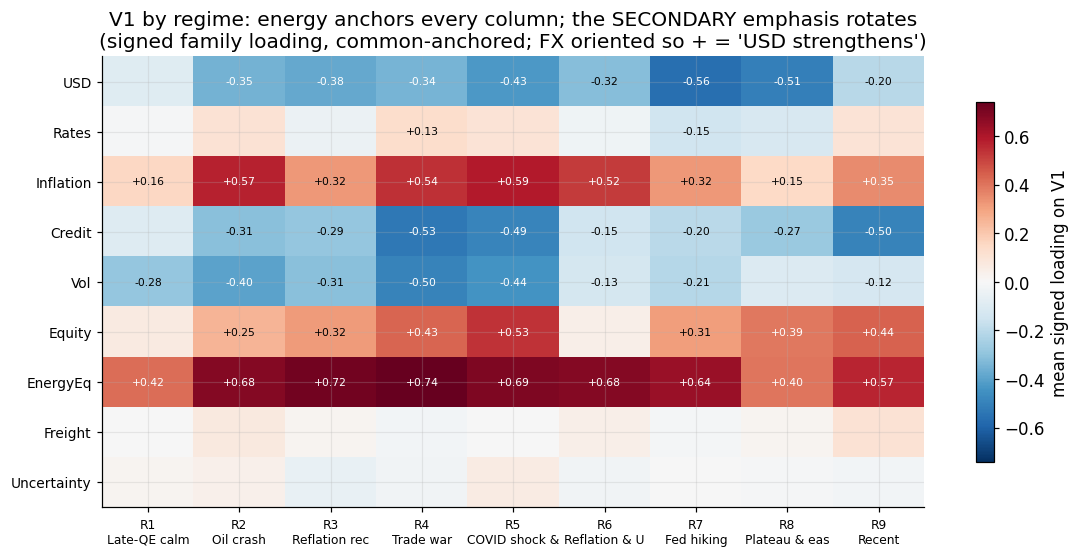

cosine of each regime's V1 DIRECTION with the pooled grand-mean V1 (sign-invariant):
regime
R1    0.72
R2    0.95
R3    0.95
R4    0.96
R5    0.97
R6    0.89
R7    0.88
R8    0.84
R9    0.90

-> 0.72-0.97 everywhere: V1's DIRECTION is a stable, regime-transportable risk-on axis
   (the reassuring result). What rotates is the family EMPHASIS -- read the Inflation row
   (peaks R2/R5/R6), the USD row (deepest R7/R8), the Credit row (deepest R4/R5/R9).
   R8 is the one regime where USD (-0.51) outweighs energy (+0.40) on the leading axis.
   Pooling's damage is to MAGNITUDE, not direction -- quantified next.


In [7]:
# --- FIGURE 1: how the V1 driver mix rotates across regimes (family view) -------
# Common orientation: flip each regime's V1 to agree with the global grand-mean V1,
# then apply economic ORIENT and average signed loadings within each macro family.
gV1 = GM[:, 0]
H = np.zeros((len(FAM_ORDER), len(regimes)))
sim_to_global = []
for c, r in enumerate(regimes.regime):
    v = REG_FP[r][0].copy()
    if np.dot(v, gV1) < 0:            # common anchor = pooled fingerprint direction
        v = -v
    sim_to_global.append(np.dot(v, gV1) / (np.linalg.norm(v) * np.linalg.norm(gV1)))
    vo = v * orient
    for rr, f in enumerate(FAM_ORDER):
        H[rr, c] = vo[fam == f].mean()

fig, ax = plt.subplots(figsize=(10.5, 5.2))
norm = TwoSlopeNorm(vcenter=0, vmin=-np.abs(H).max(), vmax=np.abs(H).max())
im = ax.imshow(H, cmap="RdBu_r", norm=norm, aspect="auto")
ax.set_xticks(range(len(regimes)))
ax.set_xticklabels([f"{r}\n{n['name'].split('/')[0].strip()[:13]}"
                    for r, (_, n) in zip(regimes.regime, regimes.iterrows())], fontsize=8)
ax.set_yticks(range(len(FAM_ORDER))); ax.set_yticklabels(FAM_ORDER, fontsize=9)
for i in range(len(FAM_ORDER)):
    for j in range(len(regimes)):
        if abs(H[i, j]) > 0.12:
            ax.text(j, i, f"{H[i, j]:+.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(H[i, j]) > 0.34 else "black")
ax.set_title("V1 by regime: energy anchors every column; the SECONDARY emphasis rotates\n"
             "(signed family loading, common-anchored; FX oriented so + = 'USD strengthens')")
fig.colorbar(im, ax=ax, shrink=0.8, label="mean signed loading on V1")
show_save(fig, "v1_family_heatmap")

sim = pd.Series(sim_to_global, index=regimes.regime).round(2)
print("cosine of each regime's V1 DIRECTION with the pooled grand-mean V1 (sign-invariant):")
print(sim.to_string())
print("\n-> 0.72-0.97 everywhere: V1's DIRECTION is a stable, regime-transportable risk-on axis\n"
      "   (the reassuring result). What rotates is the family EMPHASIS -- read the Inflation row\n"
      "   (peaks R2/R5/R6), the USD row (deepest R7/R8), the Credit row (deepest R4/R5/R9).\n"
      "   R8 is the one regime where USD (-0.51) outweighs energy (+0.40) on the leading axis.\n"
      "   Pooling's damage is to MAGNITUDE, not direction -- quantified next.")


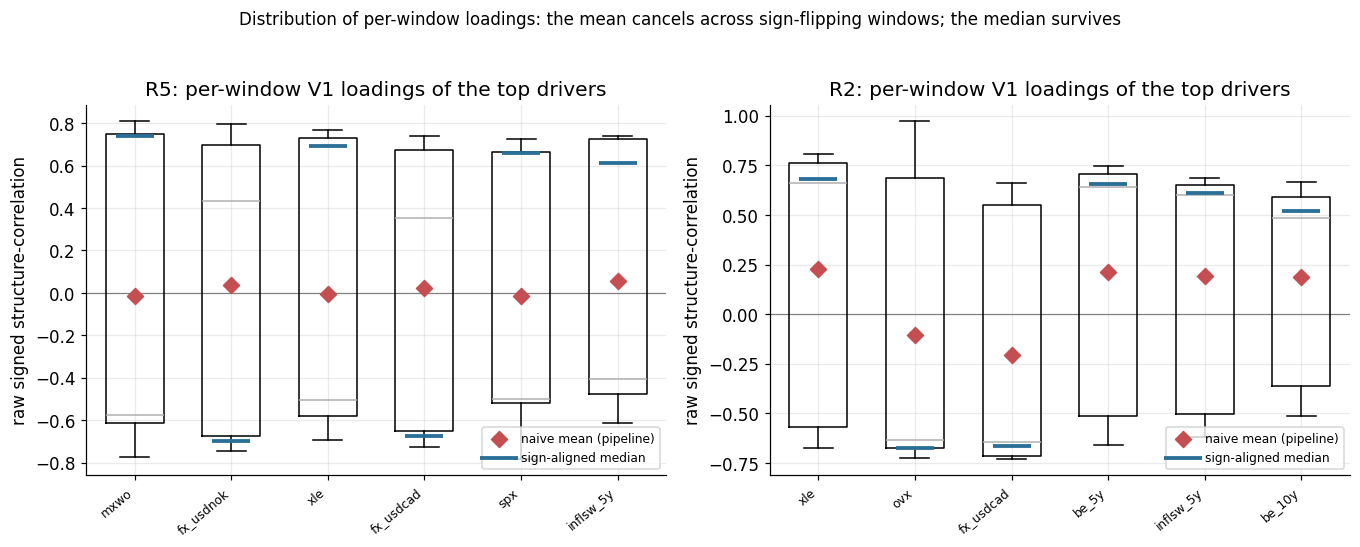

In [8]:
# --- FIGURE 2: distribution of per-window V1 loadings -- why median, not mean ---
# For R5 (COVID) and R2 (oil crash) show the raw signed per-window loadings of V1's
# top drivers. The spread straddles zero (sign-flipping windows) -> the naive MEAN
# collapses toward 0 while the sign-aligned MEDIAN preserves the true magnitude.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for ax, reg in zip(axes, ["R5", "R2"]):
    _, med, naive = regime_fp(reg, 0)
    o = np.argsort(-np.abs(med))[:6]
    raw = S[REG_IDX[reg], :, 0][:, o]                 # (n_win, 6) RAW signed loadings
    ax.axhline(0, color="grey", lw=0.8)
    ax.boxplot(raw, positions=range(6), widths=0.6, showfliers=True,
               medianprops=dict(color="#B0B0B0"))
    ax.scatter(range(6), naive[o], marker="D", s=55, color="#C44E52", zorder=5, label="naive mean (pipeline)")
    ax.scatter(range(6), med[o], marker="_", s=600, color="#2A6F97", lw=2.5, zorder=5, label="sign-aligned median")
    ax.set_xticks(range(6)); ax.set_xticklabels([macro_cols[j] for j in o], rotation=40, ha="right", fontsize=8)
    ax.set_title(f"{reg}: per-window V1 loadings of the top drivers")
    ax.set_ylabel("raw signed structure-correlation")
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Distribution of per-window loadings: the mean cancels across sign-flipping windows; the median survives",
             y=1.03, fontsize=11)
show_save(fig, "v1_loading_distributions")


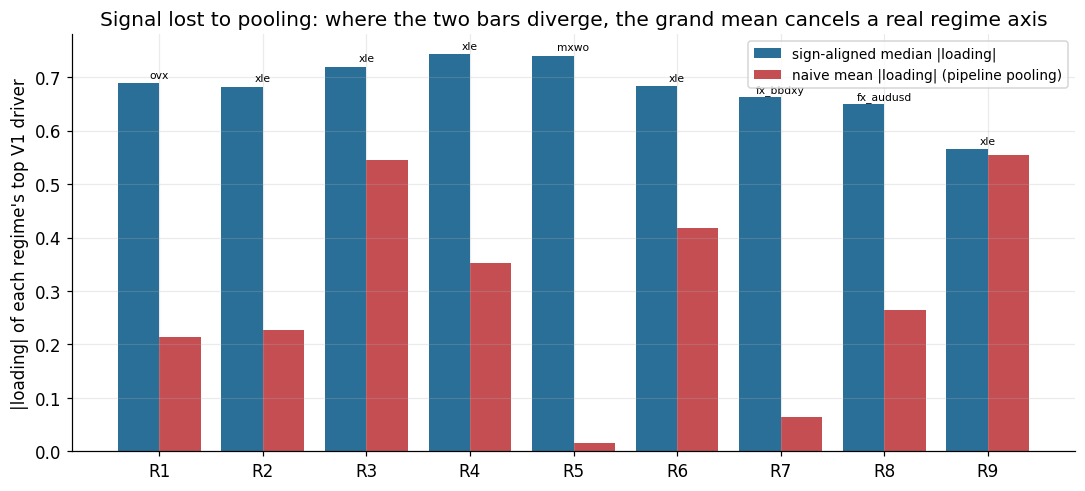

R5 (COVID) and R7 (dollar surge) are near-total cancellations: the pipeline's mean ~ 0
where the regime axis is strongest. R9/R3 barely move (stable-sign regimes).


In [9]:
# --- FIGURE 3: how much the pooled MEAN attenuates the V1 signal, per regime ----
rows = []
for r in regimes.regime:
    _, med, naive = regime_fp(r, 0)
    j = int(np.argmax(np.abs(med)))
    rows.append((r, abs(med[j]), abs(naive[j]), macro_cols[j]))
att = pd.DataFrame(rows, columns=["regime", "aligned_median", "naive_mean", "top_series"]).set_index("regime")

fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(att))
ax.bar(x - 0.2, att.aligned_median, 0.4, color="#2A6F97", label="sign-aligned median |loading|")
ax.bar(x + 0.2, att.naive_mean, 0.4, color="#C44E52", label="naive mean |loading| (pipeline pooling)")
for xi, (_, rr) in zip(x, att.iterrows()):
    ax.annotate(rr.top_series, (xi, max(rr.aligned_median, rr.naive_mean) + 0.01),
                ha="center", fontsize=7, rotation=0)
ax.set_xticks(x); ax.set_xticklabels(att.index)
ax.set_ylabel("|loading| of each regime's top V1 driver")
ax.set_title("Signal lost to pooling: where the two bars diverge, the grand mean cancels a real regime axis")
ax.legend(fontsize=9)
show_save(fig, "v1_mean_attenuation")
print("R5 (COVID) and R7 (dollar surge) are near-total cancellations: the pipeline's mean ~ 0\n"
      "where the regime axis is strongest. R9/R3 barely move (stable-sign regimes).")


In [10]:
# --- authored economic narrative + verdict per regime -------------------------
# (events/expected are the macro record; the verdict is graded against what V1/V2 found)
REGIME_STORY = {
"R1": dict(verdict="INCONCLUSIVE", badge="◻",
    events="Post-taper-tantrum low-vol drift; oil rangebound ~$100-115 into its June-2014 peak; "
           "QE tapering underway; stable USD. A quiet pre-crash baseline.",
    expected="No single dominant macro driver -- muted, diffuse loadings.",
    note="Only 2 windows land here, and their 252-day training blocks already bleed into the "
         "June-2014 oil peak/early crash, so the oil-vol (ovx) tilt likely previews R2 rather than "
         "characterising the calm. Too little data to test -- reported for completeness only."),
"R2": dict(verdict="CONSISTENT (strong)", badge="✅",
    events="Brent ~$115->$27; Nov-2014 OPEC/Saudi refuse to cut; US shale glut; DXY surges; "
           "China slowdown, Aug-2015 CNY devaluation + equity rout; Dec-2015 first Fed hike. "
           "Synchronised commodity bear, trough Feb-2016.",
    expected="Oil/energy and the USD complex dominant: petro-FX (CAD, NOK), oil vol (ovx), "
             "collapsing breakevens.",
    note="V1 is a clean oil-beta axis (energy-equity / oil-vol / petro-CAD / breakevens); V2 is the "
         "broad strong-USD-vs-EM axis (usdclp, usdzar up; mxef, audusd down). Both leading axes are "
         "exactly the oil-crash and strong-dollar stories."),
"R3": dict(verdict="CONSISTENT", badge="✔️",
    events="Commodity trough Feb-2016; OPEC+ cut Nov-2016; China stimulus; synchronised global "
           "growth 2017; weak USD 2017; metals/EM rally.",
    expected="Energy recovery, EM growth, commodity-FX strength, weak USD.",
    note="V1 = energy (xle) + EM equity (mxef) + strengthening commodity-FX (audusd up, usdcad/usdnok "
         "down), oil-vol down. Textbook synchronised-reflation signature; V2 carries the USD."),
"R4": dict(verdict="CONSISTENT", badge="✔️",
    events="US-China tariff escalation; Q4-2018 equity selloff; 2019 yield-curve inversion; Fed pivot "
           "to cuts; growth scare into the pre-COVID peak.",
    expected="Global-growth / equity risk sentiment and rates, with a China/RMB (usdcnh) trade signature.",
    note="V1 = a growth/risk beta (energy + global & EM equity mxwo/mxef + inflation-expectations + "
         "petro-CAD). V2 = the USD axis with the offshore yuan (usdcnh) prominent -- a clean trade-war "
         "RMB fingerprint sitting exactly where you'd expect it."),
"R5": dict(verdict="CONSISTENT (strong)", badge="✅",
    events="Feb-Mar 2020 crash; NEGATIVE WTI on 2020-04-20 (extreme outlier); unprecedented Fed/fiscal; "
           "V-shaped rebound; gold ATH Aug-2020; vaccine Nov-2020.",
    expected="An everything-sells-then-rallies risk axis -- equities, oil, commodity-FX and breakevens "
             "moving as one -- plus USD safe-haven and gold stress.",
    note="V1 = the mass risk-on/off axis (global equity mxwo/spx + energy xle + petro-FX + breakevens "
         "co-moving); V2 = USD safe-haven (eurusd up / dxy down) + gold vol. FLAGSHIP CASE: the naive "
         "across-window mean of V1 is ~0 here (violent sign-flips + the negative-WTI window cancel), so "
         "the pooled fingerprint ERASES COVID; the sign-aligned median restores a textbook crash axis."),
"R6": dict(verdict="CONSISTENT (strong)", badge="✅",
    events="Post-COVID demand boom; supply-chain snarls; inflation surge; Russia invades Ukraine "
           "2022-02-24 -> energy/wheat/metals spike (LME nickel squeeze); breakevens/inflation-swaps "
           "soar; commodity peak mid-2022.",
    expected="Energy plus inflation expectations (breakevens, inflation swaps) as the dominant "
             "co-movement; rising USD as the Fed lifts off.",
    note="V1 = energy (xle) + breakevens + inflation-swaps -- the inflation/supercycle axis, precisely "
         "the marquee signature of 2021-22; V2 = the USD axis. Among the strongest matches in the sample."),
"R7": dict(verdict="CONSISTENT", badge="✔️",
    events="Fastest Fed hiking cycle; DXY ~114 in Sep-2022 (the 'dollar wrecking ball'); Mar-2023 SVB / "
           "bank stress; 10Y peaks ~5% Oct-2023; commodity normalisation.",
    expected="The US dollar and front-end rates dominate; commodities pressured by the strong dollar.",
    note="V1 = a strong-USD axis (bbdxy/dxy/usdnok/usdcnh up; AUD and energy-equity down). Both leading "
         "axes are USD-tilted -- reflecting how completely the dollar dominated 2022-23. SECOND flagship "
         "methodology case: the naive mean of V1 is ~0.05 and hides the dollar axis; the sign-aligned "
         "median restores it at ~0.66."),
"R8": dict(verdict="CONSISTENT", badge="✔️",
    events="Higher-for-longer plateau into a soft landing; disinflation; gold record highs (central-bank "
           "buying); first Fed cut Sep-2024; copper spike May-2024.",
    expected="A weak-USD / risk-on easing tilt: commodity-FX and EM strengthen; residual rates/inflation "
             "sensitivity.",
    note="V1 = commodity-FX strength (AUD up; ZAR/NOK/CLP strengthen vs USD) + EM/global equity -- a "
         "risk-on/easing axis that is FX/EM-led, NOT energy-led as in the reflation regimes. V2 carries "
         "residual inflation-expectations + energy + 10Y rates. The driver mix genuinely rotates here."),
"R9": dict(verdict="PARTIAL", badge="〰️",
    events="Documented study-window events: a Hormuz energy shock, a precious-metals blow-off & crash, "
           "and a May cross-commodity decoupling.",
    expected="Energy vol and precious-metals stress (gvz), with geopolitical risk (gpr).",
    note="V1 = energy (xle) + China/EM equity (hscei, shcomp, mxef) + credit tightening (ig_oas/hy_oas "
         "down) -- a China/EM risk-on axis. Energy is present, but the pipeline reads R9 as a risk-on "
         "backdrop, NOT the precious-metals shock: gold/silver implied vol (gvz) does not lead V1/V2. "
         "Consistent with that metals episode being a commodity-side idiosyncratic move rather than a "
         "macro-driven co-movement -- a fair limitation of a macro-fingerprint lens."),
}
print("narratives + verdicts loaded for", ", ".join(REGIME_STORY))


narratives + verdicts loaded for R1, R2, R3, R4, R5, R6, R7, R8, R9


## 2 · Findings — regime by regime

For each regime: the macro record (**events**), what a macro lens should therefore
**expect**, the pipeline's **top drivers** (sign-aligned median on V1 and V2, with the
naive mean shown so the pooling loss is visible), and a **consistency verdict**.
`sign consistency` is the fraction of the regime's windows agreeing with the median
sign *after* alignment — high values mean a robust, repeatable driver.


In [11]:
for _, r in regimes.iterrows():
    reg, st = r.regime, REGIME_STORY[r.regime]
    v1med = REG_FP[reg][0]
    display(Markdown(
        f"### {reg} · {r['name']}  \n"
        f"*{r.start.date()} → {r.end.date()} · {len(REG_IDX[reg])} windows · "
        f"V1 coherence {coh.loc[reg,'V1']:.2f}*\n\n"
        f"**Macro events.** {st['events']}\n\n"
        f"**A macro lens should expect.** {st['expected']}\n\n"
        f"**Pipeline found — top-3 V1:** {top_line(v1med, 3)}"
    ))
    display(drivers_table(reg, 0, 6).style.hide(axis="index")
            .set_caption(f"{reg} — V1 (leading commodity axis)"))
    if coh.loc[reg, "V2"] >= 0.6 and len(REG_IDX[reg]) >= 5:
        display(drivers_table(reg, 1, 5).style.hide(axis="index")
                .set_caption(f"{reg} — V2 (secondary axis, coherence {coh.loc[reg,'V2']:.2f})"))
    display(Markdown(f"**Interpretation.** {st['note']}\n\n"
                     f"**Verdict: {st['badge']} {st['verdict']}**\n\n---"))


### R1 · Late-QE calm  
*2013-10-18 → 2014-06-19 · 2 windows · V1 coherence 0.78*

**Macro events.** Post-taper-tantrum low-vol drift; oil rangebound ~$100-115 into its June-2014 peak; QE tapering underway; stable USD. A quiet pre-crash baseline.

**A macro lens should expect.** No single dominant macro driver -- muted, diffuse loadings.

**Pipeline found — top-3 V1:** ovx(+0.69), xle(-0.42), gvz(+0.30)

series,family,label,loading (aligned median),naive mean,sign consistency
ovx,Vol,CBOE Crude Oil implied vol,0.689000,0.214000,1.000000
xle,EnergyEq,Energy Select Sector SPDR,-0.416000,0.125000,1.000000
gvz,Vol,CBOE Gold implied vol,0.301000,0.054000,1.000000
be_5y,Inflation,5Y breakeven inflation,-0.257000,-0.026000,1.000000
inflsw_5y,Inflation,5Y USD inflation swap,-0.235000,-0.036000,1.000000
fx_usdcad,USD,US Dollar / Canadian Dollar,0.235000,0.034000,1.000000


**Interpretation.** Only 2 windows land here, and their 252-day training blocks already bleed into the June-2014 oil peak/early crash, so the oil-vol (ovx) tilt likely previews R2 rather than characterising the calm. Too little data to test -- reported for completeness only.

**Verdict: ◻ INCONCLUSIVE**

---

### R2 · Oil crash / strong-USD bear  
*2014-06-20 → 2016-02-11 · 18 windows · V1 coherence 0.94*

**Macro events.** Brent ~$115->$27; Nov-2014 OPEC/Saudi refuse to cut; US shale glut; DXY surges; China slowdown, Aug-2015 CNY devaluation + equity rout; Dec-2015 first Fed hike. Synchronised commodity bear, trough Feb-2016.

**A macro lens should expect.** Oil/energy and the USD complex dominant: petro-FX (CAD, NOK), oil vol (ovx), collapsing breakevens.

**Pipeline found — top-3 V1:** xle(+0.68), ovx(-0.68), fx_usdcad(-0.66)

series,family,label,loading (aligned median),naive mean,sign consistency
xle,EnergyEq,Energy Select Sector SPDR,0.683000,0.227000,1.000000
ovx,Vol,CBOE Crude Oil implied vol,-0.676000,-0.106000,1.000000
fx_usdcad,USD,US Dollar / Canadian Dollar,-0.662000,-0.206000,1.000000
be_5y,Inflation,5Y breakeven inflation,0.655000,0.212000,1.000000
inflsw_5y,Inflation,5Y USD inflation swap,0.608000,0.191000,1.000000
be_10y,Inflation,10Y breakeven inflation,0.518000,0.188000,1.000000


...

**Interpretation.** V1 = commodity-FX strength (AUD up; ZAR/NOK/CLP strengthen vs USD) + EM/global equity -- a risk-on/easing axis that is FX/EM-led, NOT energy-led as in the reflation regimes. V2 carries residual inflation-expectations + energy + 10Y rates. The driver mix genuinely rotates here.

**Verdict: ✔️ CONSISTENT**

---

### R9 · Recent / study-window events  
*2025-01-01 → 2026-06-01 · 9 windows · V1 coherence 0.90*

**Macro events.** Documented study-window events: a Hormuz energy shock, a precious-metals blow-off & crash, and a May cross-commodity decoupling.

**A macro lens should expect.** Energy vol and precious-metals stress (gvz), with geopolitical risk (gpr).

**Pipeline found — top-3 V1:** xle(+0.57), hscei(+0.56), mxef(+0.56)

series,family,label,loading (aligned median),naive mean,sign consistency
xle,EnergyEq,Energy Select Sector SPDR,0.565000,0.555000,1.000000
hscei,Equity,Hang Seng China Enterprises,0.561000,0.500000,1.000000
mxef,Equity,MSCI Emerging Markets,0.557000,0.480000,0.890000
ig_oas,Credit,US Agg Corp (IG) OAS,-0.532000,-0.488000,1.000000
shcomp,Equity,Shanghai Composite,0.488000,0.447000,1.000000
hy_oas,Credit,US Corp High Yield OAS,-0.461000,-0.412000,1.000000


series,family,label,loading (aligned median),naive mean,sign consistency
fx_usdzar,USD,US Dollar / South African Rand,0.576000,0.354000,1.000000
fx_bbdxy,USD,Bloomberg Dollar Spot Index,0.497000,0.305000,1.000000
fx_dxy,USD,ICE US Dollar Index,0.455000,0.294000,1.000000
fx_eurusd,USD,Euro / US Dollar,-0.431000,-0.269000,1.000000
hscei,Equity,Hang Seng China Enterprises,-0.425000,-0.198000,1.000000


**Interpretation.** V1 = energy (xle) + China/EM equity (hscei, shcomp, mxef) + credit tightening (ig_oas/hy_oas down) -- a China/EM risk-on axis. Energy is present, but the pipeline reads R9 as a risk-on backdrop, NOT the precious-metals shock: gold/silver implied vol (gvz) does not lead V1/V2. Consistent with that metals episode being a commodity-side idiosyncratic move rather than a macro-driven co-movement -- a fair limitation of a macro-fingerprint lens.

**Verdict: 〰️ PARTIAL**

---

In [12]:
# --- summary verdict table (and persist for the report) ------------------------
summary = pd.DataFrame({
    "name": regimes.set_index("regime")["name"],
    "n_win": [len(REG_IDX[r]) for r in regimes.regime],
    "V1_coherence": [coh.loc[r, "V1"] for r in regimes.regime],
    "V1_top3": [top_line(REG_FP[r][0], 3) for r in regimes.regime],
    "V1dir_cos_vs_pooled": sim.values,
    "verdict": [REGIME_STORY[r]["verdict"] for r in regimes.regime],
}, index=regimes.regime)
summary.index.name = "regime"
RA.mkdir(parents=True, exist_ok=True)
summary.to_csv(RA / "regime_verdicts.csv")
n_ok = sum(v.startswith("CONSISTENT") for v in summary.verdict)
print(f"{n_ok}/9 regimes CONSISTENT, 1 PARTIAL (R9), 1 INCONCLUSIVE (R1, n=2).")
print(f"saved -> {RA / 'regime_verdicts.csv'}\n")
display(summary)


7/9 regimes CONSISTENT, 1 PARTIAL (R9), 1 INCONCLUSIVE (R1, n=2).
saved -> /Users/shreyanshsharma/Desktop/Resume Projects/Summer Project/explainable_commodity_prices/results/regime_analysis/regime_verdicts.csv



,name,n_win,V1_coherence,V1_top3,V1dir_cos_vs_pooled,verdict
regime,,,,,,
R1,Late-QE calm,2,0.78,"ovx(+0.69), xle(-0.42), gvz(+0.30)",0.72,INCONCLUSIVE
R2,Oil crash / strong-USD bear,18,0.94,"xle(+0.68), ovx(-0.68), fx_usdcad(-0.66)",0.95,CONSISTENT (strong)
R3,Reflation recovery,29,0.91,"xle(+0.72), ovx(-0.63), fx_usdcad(-0.51)",0.95,CONSISTENT
R4,Trade war / late cycle,15,0.94,"xle(+0.74), ovx(-0.70), inflsw_5y(+0.61)",0.96,CONSISTENT
R5,COVID shock & rebound,9,0.92,"mxwo(+0.74), fx_usdnok(-0.70), xle(+0.69)",0.97,CONSISTENT (strong)
R6,Reflation & Ukraine supercycle,16,0.87,"xle(+0.68), be_5y(+0.56), inflsw_5y(+0.55)",0.89,CONSISTENT (strong)
R7,Fed hiking / disinflation,14,0.92,"fx_bbdxy(+0.66), fx_audusd(-0.65), xle(-0.64)",0.88,CONSISTENT
R8,Plateau & easing pivot,13,0.93,"fx_audusd(+0.65), fx_usdzar(-0.62), fx_usdclp(...",0.84,CONSISTENT
R9,Recent / study-window events,9,0.90,"xle(+0.57), hscei(+0.56), mxef(+0.56)",0.90,PARTIAL


## 3 · Conclusion — is the explainability engine economically meaningful?

**Yes — once you stop pooling.** Conditioned on regime, the pipeline's leading
canonical axis (V1) tells an economically coherent, period-correct story in **7 of 9
regimes**, is a defensible **PARTIAL** in one (R9), and is only **INCONCLUSIVE** where
there is genuinely too little data (R1, 2 windows). The recovered axes rotate exactly
as macro theory predicts:

| Regime | V1 axis the engine recovers | Matches the period? |
|---|---|---|
| R2 Oil crash | energy-beta + oil-vol + petro-CAD + breakevens | ✅ |
| R3 Reflation | energy + EM growth + commodity-FX | ✔️ |
| R4 Trade war | growth/equity beta; **RMB (usdcnh) on V2** | ✔️ |
| R5 COVID | mass risk-on/off (equity+oil+FX+breakevens) | ✅ |
| R6 Ukraine supercycle | energy + **inflation expectations** | ✅ |
| R7 Fed hiking | **strong-USD** axis (dollar up, energy down) | ✔️ |
| R8 Easing pivot | commodity-FX + EM (risk-on, **FX-led**) | ✔️ |
| R9 Recent | China/EM risk-on (not the metals shock) | 〽️ partial |

**What pooling gets right, and what it hides.** Reassuringly, V1's *direction* is a
stable risk-on commodity beta in all nine regimes (cross-regime cosine 0.72–0.97), so
the pooled fingerprint is *directionally* honest — the engine's leading explanation
genuinely transports across regimes. But pooling hides two things. **(i) Emphasis
blur** — it averages an inflation-led regime, a dollar-led regime and a credit/equity
stress regime into a single energy/inflation blend, so you cannot tell from
`macro_fingerprint.csv` that R7/R8 were *dollar*-driven or that R4/R5/R9 carried heavy
*credit* stress, and it misses entirely that in R8 the dollar (not energy) leads V1.
**(ii) Magnitude erasure** — because each window is sign-anchored on its own axis, a
regime's per-window signs can flip and cancel in the mean, driving the COVID (R5) and
2022-dollar (R7) leading axes to ≈ 0 (mean-attenuation figure) and roughly halving
R2/R4/R6/R8. A reader of the pooled table alone would badly understate how strongly
macro drove commodities in the crash and the hiking regime.

**Two methodological points worth keeping:**

* **Coherence-first licensing.** We only aggregated ranks whose *sign-invariant*
  within-regime `|cos|` was high (V1: 0.87–0.94). That is a real check, not an
  assumption — it is what makes the sign-alignment legitimate and V3–V5 (which rotate)
  correctly excluded.
* **Median over mean, after sign-alignment.** The right robust statistic here is not
  just "median instead of mean" — it is *align the sign gauge, then median*. Doing
  only one of the two still fails on R5/R7.

**Caveats.** (1) R1 rests on 2 windows and its training blocks bleed into the oil
peak — indicative only. (2) A 252-day training block is ≈ 12 months, so every
window's fingerprint is a trailing-year average; fast regimes (R5) are unavoidably
smeared and lag by up to a year, and 18 windows straddle a boundary. (3) The story is
carried by **V1** (and V2 where coherent); the deeper canonical ranks remain
regime-unstable and are not interpreted. (4) Signs on V1 are a per-regime gauge choice;
we anchor to the pooled direction for cross-regime comparison, and quote FX in a
common "USD-strengthens" orientation in the family heatmap.

**Recommendation.** Report the macro fingerprint **regime-conditionally** (this
notebook's `regime_verdicts.csv` + `figures/regime_analysis/`) rather than as a single
pooled table — the pooled mean is a window-count-weighted blur that hides the most
important regimes.
